In [2]:
#reducing overfiiting

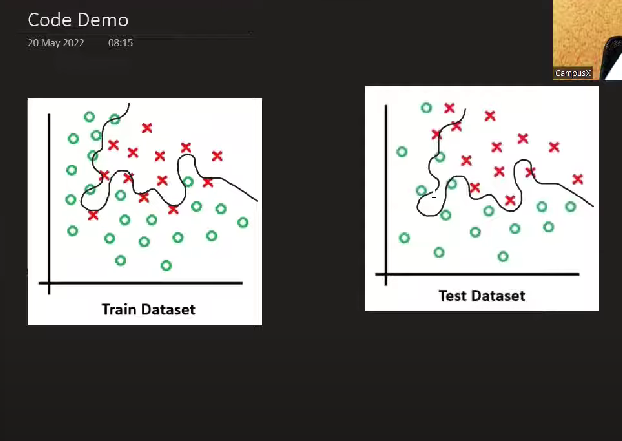


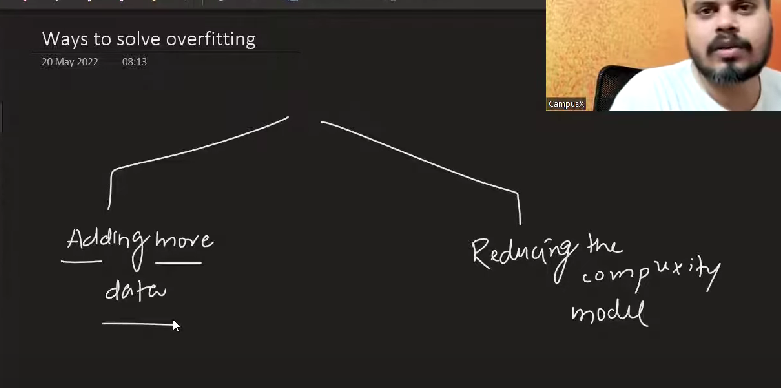

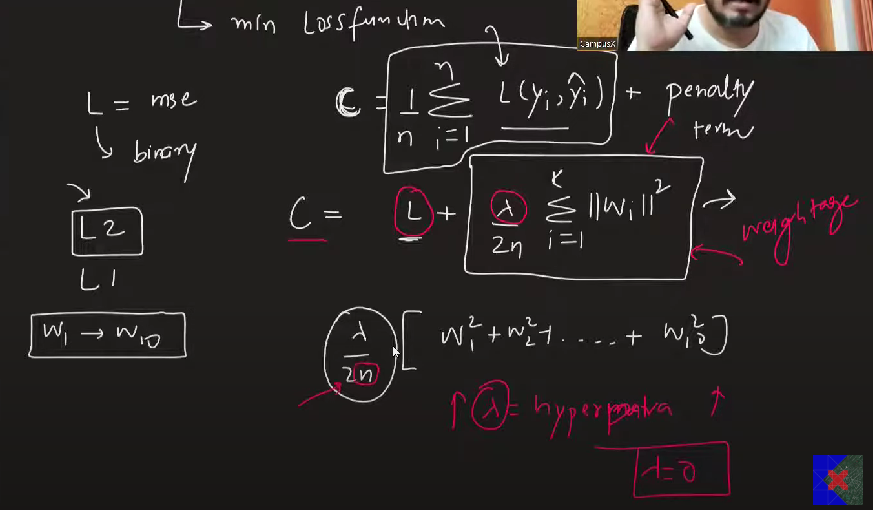

In [9]:
#yha lambda ek hyperparamter hai jiski value badhane se underfitting support hoti and n no of rows hai
#penality lgane se weights ki value zero ki taraf tends krne lg jaati hai 
#l1 ke case me me ye sqare term nhi hoga panality me 

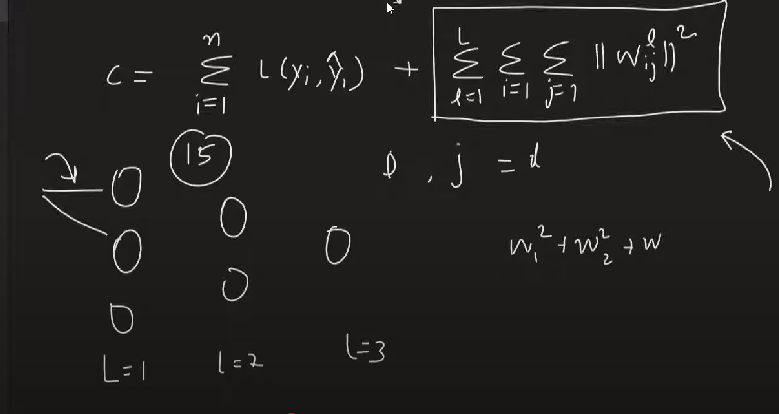

In [12]:
# i is row j is col and layer is l

<h1>Intitution behind Regulization</h1>

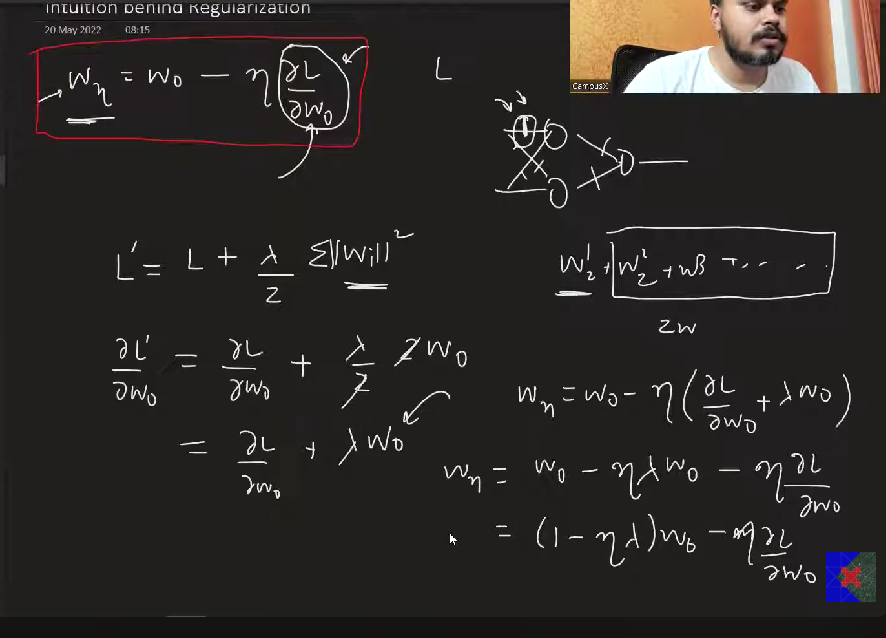

In [16]:
#this clearly shows weight reduce and it tendence to zero and this is also called weight decay 

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

In [20]:
X, y = make_moons(100, noise=0.25,random_state=2)

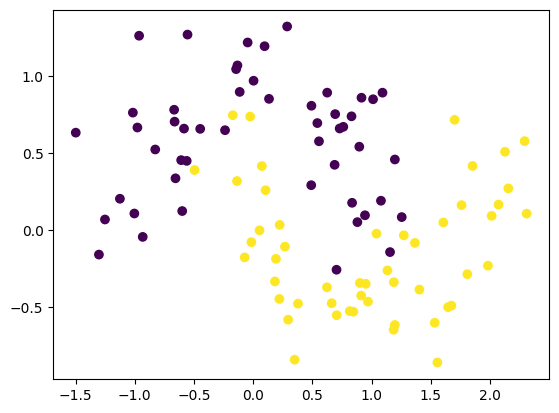

In [22]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

In [24]:
model1 = Sequential()

model1.add(Dense(128,input_dim=2, activation="relu"))
model1.add(Dense(128, activation="relu"))
model1.add(Dense(1,activation='sigmoid'))

model1.summary()

C:\Users\Jatin\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
adam = Adam(learning_rate=0.01)
model1.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history1 = model1.fit(X, y, epochs=2000, validation_split = 0.2,verbose=0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 9s 923us/step


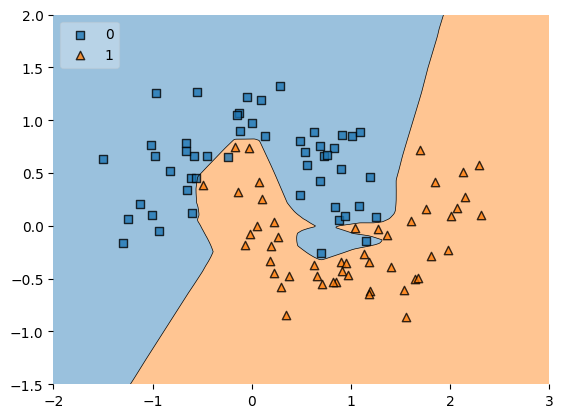

In [28]:
plot_decision_regions(X, y.astype('int'), clf=model1, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

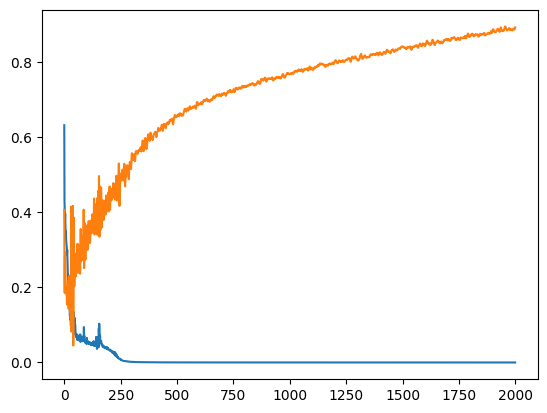

In [30]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])

In [32]:
model2 = Sequential()

model2.add(Dense(128,input_dim=2, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l1(0.001)))
model2.add(Dense(128, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l1(0.001)))
model2.add(Dense(1,activation='sigmoid'))

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 128)                 │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
adam = Adam(learning_rate=0.01)
model2.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history2 = model2.fit(X, y, epochs=2000, validation_split = 0.2,verbose=0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 8s 843us/step


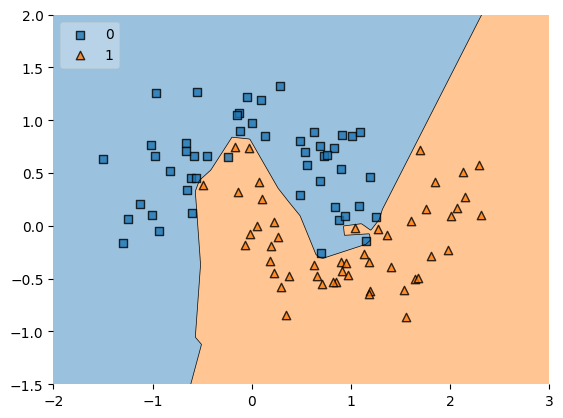

In [36]:
plot_decision_regions(X, y.astype('int'), clf=model2, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

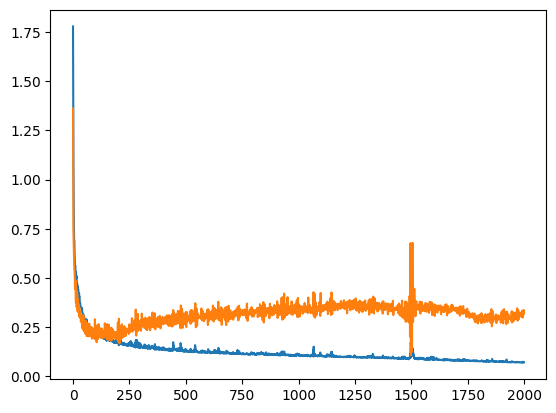

In [38]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])

In [42]:
model1.get_weights()[0].shape

(2, 128)

In [44]:
# 2 input and first layer has 128 nodes

In [46]:
model1.get_weights()[0].reshape(256)

array([ 2.49978647e-01, -2.77610987e-01,  5.90184815e-02, -5.20466745e-01,
       -4.34888184e-01, -4.06413019e-01,  2.26061046e-01, -4.37246144e-01,
        6.05862290e-02, -4.79889423e-01, -4.28848416e-01,  2.11784858e-02,
        2.40636289e-01, -8.19088817e-02,  1.26910135e-01, -1.25793517e-01,
       -2.79802948e-01, -1.82126790e-01, -4.93088841e-01,  1.91808447e-01,
       -2.24687338e-01, -5.98015428e-01, -4.55862343e-01, -2.87607685e-02,
        2.04961300e-01,  2.00072482e-01,  1.59986496e-01, -2.75689334e-01,
       -4.26467098e-02, -7.71728382e-02,  9.27981734e-02,  2.42951326e-02,
        2.06983685e-02, -1.10034309e-01,  5.46012260e-02,  2.25766450e-01,
        3.00239444e-01,  8.92397165e-02,  2.82700211e-01, -1.97223172e-01,
        2.14354947e-01, -3.26679468e-01, -5.78338206e-01,  8.49502459e-02,
        1.85816452e-01, -3.51327769e-02,  2.31064707e-01,  2.83644646e-01,
       -1.26559183e-01,  2.56749213e-01, -4.80730146e-01, -3.95569801e-01,
        2.88375050e-01, -

In [48]:
model1_weight_layer1 = model1.get_weights()[0].reshape(256)
model2_weight_layer1 = model2.get_weights()[0].reshape(256)

<Axes: >

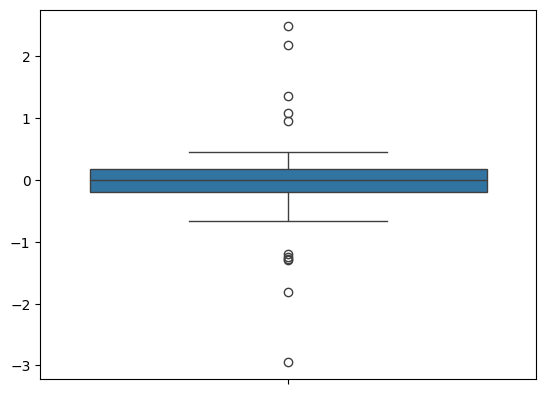

In [50]:
sns.boxplot(model1_weight_layer1)

<Axes: >

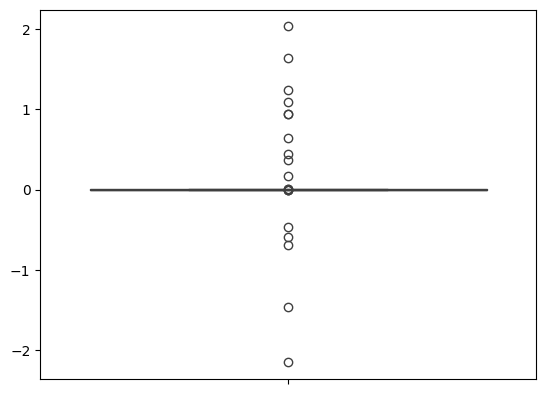

In [52]:
sns.boxplot(model2_weight_layer1)

In [54]:
model2_weight_layer1.min()

-2.152571

In [56]:
model2_weight_layer1.max()

2.0327349

In [60]:
#zad trr weights zero ki taraf tend hore

C:\Users\Jatin\AppData\Local\Temp\ipykernel_25132\2224180084.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(model1_weight_layer1)
C:\Users\Jatin\AppData\Local\Temp\ipykernel_25132\2224180084.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(model2_weight_layer1)


<Axes: ylabel='Density'>

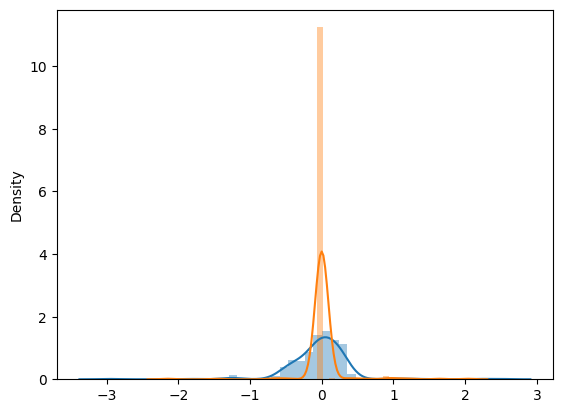

In [62]:
sns.distplot(model1_weight_layer1)
sns.distplot(model2_weight_layer1)

In [64]:
#zada trr value zero ki taraf lie kr rhi 